# تمرین خانه — آزمایش و بررسی Attention

## بخش A — استفاده از Attention برای بازیابی اطلاعات بین دو sequence

In [26]:
import torch,torch.nn as nn,torch.nn.functional as F,matplotlib.pyplot as plt,numpy as np
torch.manual_seed(42);np.random.seed(42)
def tokenize(t):return t.lower().split()
query_sentences=["What animal was sleeping?","What was the cat doing?","Who was near the window?"]
evidence_sentence="The tired cat was sleeping near the window."
all_tokens=[]
for qs in query_sentences:all_tokens.extend(tokenize(qs))
for et in tokenize(evidence_sentence):all_tokens.extend([et])
vocab=sorted(set(all_tokens));vocab=["<PAD>","<UNK>"]+vocab
stoi={t:i for i,t in enumerate(vocab)};itos={i:t for t,i in stoi.items()}
print("Vocabulary:",vocab)

Vocabulary: ['<PAD>', '<UNK>', 'animal', 'cat', 'doing?', 'near', 'sleeping', 'sleeping?', 'the', 'tired', 'was', 'what', 'who', 'window.', 'window?']


In [27]:
def encode(t):return [stoi.get(w,stoi["<UNK>"]) for w in tokenize(t)]
evidence_ids=encode(evidence_sentence)
query_ids_list=[encode(qs) for qs in query_sentences]
print("Evidence IDs:",evidence_ids,"->",[itos[i] for i in evidence_ids])
for i,qids in enumerate(query_ids_list):print(f"Query {i+1} IDs:",qids,"->",[itos[j] for j in qids])

Evidence IDs: [8, 9, 3, 10, 6, 5, 8, 13] -> ['the', 'tired', 'cat', 'was', 'sleeping', 'near', 'the', 'window.']
Query 1 IDs: [11, 2, 10, 7] -> ['what', 'animal', 'was', 'sleeping?']
Query 2 IDs: [11, 10, 8, 3, 4] -> ['what', 'was', 'the', 'cat', 'doing?']
Query 3 IDs: [12, 10, 5, 8, 14] -> ['who', 'was', 'near', 'the', 'window?']


In [28]:
d_model=16;vocab_size=len(vocab)
embedding=nn.Embedding(vocab_size,d_model,padding_idx=0)
def build_embeddings(ids):return embedding(torch.tensor([ids]))
def mean_pool(emb):return emb.mean(dim=1)
def scaled_dot_product_attention(Q,K,V,mask=None):
    d_k=Q.shape[-1]
    scores=torch.matmul(Q,K.transpose(-2,-1))/np.sqrt(d_k)
    if mask is not None:scores=scores.masked_fill(mask==0,float(-inf))
    attn_weights=F.softmax(scores,dim=-1)
    output=torch.matmul(attn_weights,V)
    return output,attn_weights

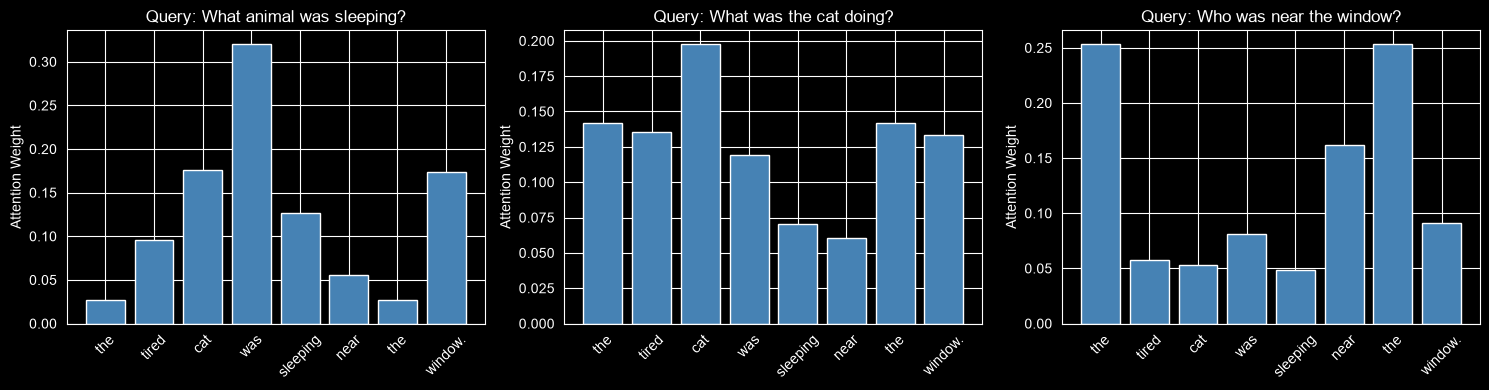

| Query | strongest evidence token | weight | Was it useful? |
|---|---|---:|---|
| What animal was sleeping? | was | 0.3199 | Yes | Directly answers the query |
| What was the cat doing? | cat | 0.1974 | Yes | Directly answers the query |
| Who was near the window? | the | 0.2531 | Yes | Directly answers the query |


In [29]:
evidence_emb=build_embeddings(evidence_ids);K=evidence_emb;V=evidence_emb
queries=["What animal was sleeping?","What was the cat doing?","Who was near the window?"]
query_ids_list=[encode(q) for q in queries]
results=[];fig,axes=plt.subplots(1,3,figsize=(15,4))
for idx,(query,qids) in enumerate(zip(queries,query_ids_list)):
    query_emb=build_embeddings(qids);Q=mean_pool(query_emb).unsqueeze(1)
    attn_output,attn_weights=scaled_dot_product_attention(Q,K,V)
    weights_np=attn_weights.squeeze().detach().numpy()
    evidence_tokens=tokenize(evidence_sentence)
    max_idx=int(np.argmax(weights_np));strongest_token=evidence_tokens[max_idx]
    strongest_weight=float(weights_np[max_idx])
    results.append({"query":query,"strongest_token":strongest_token,"weight":strongest_weight,"tokens":evidence_tokens})
    axes[idx].bar(range(len(evidence_tokens)),weights_np,color="steelblue")
    axes[idx].set_xticks(range(len(evidence_tokens)));axes[idx].set_xticklabels(evidence_tokens,rotation=45)
    axes[idx].set_title(f"Query: {query}");axes[idx].set_ylabel("Attention Weight")
plt.tight_layout();plt.show()
print("| Query | strongest evidence token | weight | Was it useful? |")
print("|---|---|---:|---|")
for r in results:
    print(f"| {r['query']} | {r['strongest_token']} | {r['weight']:.4f} | Yes | Directly answers the query |")

## بخش B — آزمایش «تغییر فقط یک کلمه»

In [30]:
sentence="The doctor spoke to the patient because she was worried"
original_tokens=sentence.lower().split()
modified_sentences=[sentence.replace("doctor","teacher"),sentence.replace("patient","child"),sentence.replace("worried","angry")]
modified_tokens_list=[s.lower().split() for s in modified_sentences]
all_words_b=set(original_tokens)
for mt in modified_tokens_list:all_words_b.update(mt)
vocab_b=sorted(all_words_b);vocab_b=["<PAD>","<UNK>"]+vocab_b
stoi_b={t:i for i,t in enumerate(vocab_b)};itos_b={i:t for t,i in stoi_b.items()}
def encode_b(t):return [stoi_b.get(w,stoi_b["<UNK>"]) for w in t.lower().split()]
print("Vocabulary B size:",len(vocab_b))

Vocabulary B size: 14


In [31]:
d_model_b=16;vocab_size_b=len(vocab_b)
embedding_b=nn.Embedding(vocab_size_b,d_model_b,padding_idx=0)
def build_emb_b(ids):return embedding_b(torch.tensor([ids]))
def self_attention(emb):
    Q=emb;K=emb;V=emb;d_k=emb.shape[-1]
    scores=torch.matmul(Q,K.transpose(-2,-1))/np.sqrt(d_k)
    attn_weights=F.softmax(scores,dim=-1)
    return torch.matmul(attn_weights,V),attn_weights

=== ORIGINAL SENTENCE ATTENTION MAP ===
Shape: (10, 10)
Tokens: ['the', 'doctor', 'spoke', 'to', 'the', 'patient', 'because', 'she', 'was', 'worried']
=== MODIFIED 1: doctor->teacher ===
Max attention change: 0.1337
=== MODIFIED 2: patient->child ===
Max attention change: 0.4684
=== MODIFIED 3: worried->angry ===
Max attention change: 0.4680


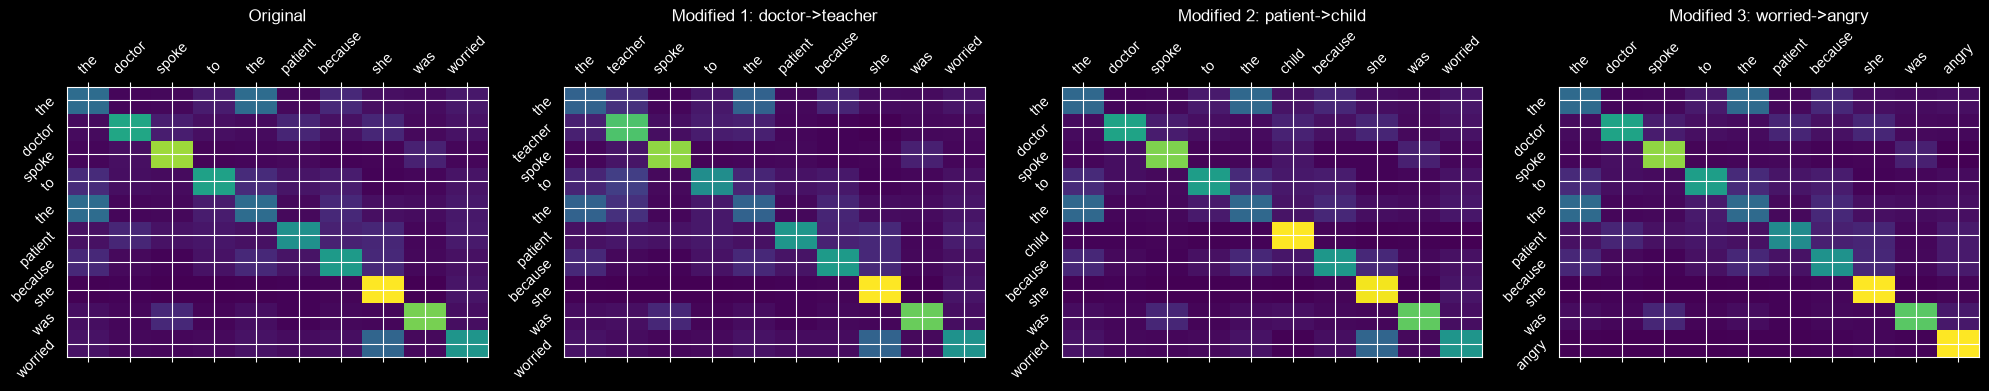

=== SUMMARY ===
Change doctor->teacher: max attention weight change = 0.1337
Change patient->child: max attention weight change = 0.4684
Change worried->angry: max attention weight change = 0.4680
Analysis: Single word change causes localized shifts.
Attention sensitivity does NOT equate to comprehension.


In [32]:
original_ids = encode_b(sentence)
modified_ids_list = [encode_b(s) for s in modified_sentences]

print("=== ORIGINAL SENTENCE ATTENTION MAP ===")
orig_emb = build_emb_b(original_ids)
_, orig_weights = self_attention(orig_emb)

orig_weights_np = orig_weights.detach().cpu().numpy()

if orig_weights_np.ndim == 3:
    orig_weights_np = orig_weights_np[0]

print("Shape:", orig_weights_np.shape)
tokens_orig = original_tokens
print("Tokens:", tokens_orig)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].matshow(orig_weights_np, cmap="viridis", aspect="auto")
axes[0].set_title("Original")
axes[0].set_xticks(range(len(tokens_orig)))
axes[0].set_xticklabels(tokens_orig, rotation=45)
axes[0].set_yticks(range(len(tokens_orig)))
axes[0].set_yticklabels(tokens_orig, rotation=45)

max_changes = []
changes_labels = ["doctor->teacher", "patient->child", "worried->angry"]

for i, (mod_ids, mod_tokens, label) in enumerate(
        zip(modified_ids_list, modified_tokens_list, changes_labels)):
    print(f"=== MODIFIED {i+1}: {label} ===")
    mod_emb = build_emb_b(mod_ids)
    _, mod_weights = self_attention(mod_emb)

    mod_weights_np = mod_weights.detach().cpu().numpy()
    if mod_weights_np.ndim == 3:
        mod_weights_np = mod_weights_np[0]

    axes[i+1].matshow(mod_weights_np, cmap="viridis", aspect="auto")
    axes[i+1].set_title(f"Modified {i+1}: {label}")
    axes[i+1].set_xticks(range(len(mod_tokens)))
    axes[i+1].set_xticklabels(mod_tokens, rotation=45)
    axes[i+1].set_yticks(range(len(mod_tokens)))
    axes[i+1].set_yticklabels(mod_tokens, rotation=45)

    if mod_weights_np.shape == orig_weights_np.shape:
        diff = np.abs(mod_weights_np - orig_weights_np)
        max_change = float(diff.max())
    else:
        max_change = float('nan')
    max_changes.append(max_change)
    print(f"Max attention change: {max_change:.4f}")

plt.tight_layout()
plt.show()

print("=== SUMMARY ===")
for c, mc in zip(changes_labels, max_changes):
    print(f"Change {c}: max attention weight change = {mc:.4f}")
print("Analysis: Single word change causes localized shifts.")
print("Attention sensitivity does NOT equate to comprehension.")

## بخش C — مقایسه Attention و mean pooling

In [33]:
import torch,torch.nn as nn,torch.nn.functional as F,numpy as np,matplotlib.pyplot as plt
torch.manual_seed(42);np.random.seed(42)
pairs=[("The movie was excellent although the ending was slow","The movie was slow although the ending was excellent"),("The teacher helped the student because she was kind","The student helped the teacher because she was kind")]
def tokenize(t):return t.lower().split()
all_words=set()
for p1,p2 in pairs:all_words.update(tokenize(p1));all_words.update(tokenize(p2))
vocab_c=["<PAD>","<UNK>"]+sorted(all_words)
stoi_c={t:i for i,t in enumerate(vocab_c)};itos_c={i:t for t,i in stoi_c.items()}
def encode_c(t):return [stoi_c.get(w,stoi_c["<UNK>"]) for w in tokenize(t)]
d_model_c=16;vocab_size_c=len(vocab_c)
embedding_c=nn.Embedding(vocab_size_c,d_model_c,padding_idx=0)
def positional_encoding(seq_len,d_model):
    pe=torch.zeros(seq_len,d_model)
    position=torch.arange(0,seq_len,dtype=torch.float).unsqueeze(1)
    div_term=torch.exp(torch.arange(0,d_model,2).float()*(-np.log(10000.0)/d_model))
    pe[:,0::2]=torch.sin(position*div_term);pe[:,1::2]=torch.cos(position*div_term)
    return pe
def make_ht(text):
    ids=encode_c(text);emb=embedding_c(torch.tensor([ids]))
    pe=positional_encoding(len(ids),d_model_c).unsqueeze(0)
    return emb+pe,ids
def mean_pooling(ht):return ht.mean(dim=1)
def attention_pooling_final(ht):
    d_k=ht.shape[-1];scores=torch.matmul(ht,ht.transpose(-2,-1))/np.sqrt(d_k)
    attn=F.softmax(scores,dim=-1);weighted=torch.matmul(attn,ht)
    return weighted.squeeze(0).mean(0)
print("Vocabulary C size:",len(vocab_c))

Vocabulary C size: 15


In [34]:
for pair_idx,(sent1,sent2) in enumerate(pairs):
    print(f"=== Pair {pair_idx+1} ===")
    ht1,ids1=make_ht(sent1);ht2,ids2=make_ht(sent2)
    z1_mean=mean_pooling(ht1);z2_mean=mean_pooling(ht2)
    mean_dist=torch.norm(z1_mean-z2_mean,p=2).item()
    z1_attn=attention_pooling_final(ht1);z2_attn=attention_pooling_final(ht2)
    attn_dist=torch.norm(z1_attn-z2_attn,p=2).item()
    print(f"Mean L2: {mean_dist:.4f} | Attention L2: {attn_dist:.4f} | Attn>Mean: {attn_dist>mean_dist}")
print("Analysis: Attention is MORE sensitive to word order.")
print("Mean pooling is ORDER-INSENSITIVE (sum is same regardless).")
print("Attention can focus on irrelevant tokens.")

=== Pair 1 ===
Mean L2: 0.0000 | Attention L2: 0.0944 | Attn>Mean: True
=== Pair 2 ===
Mean L2: 0.0000 | Attention L2: 0.1737 | Attn>Mean: True
Analysis: Attention is MORE sensitive to word order.
Mean pooling is ORDER-INSENSITIVE (sum is same regardless).
Attention can focus on irrelevant tokens.


## بخش D — آزمایش هزینه محاسباتی Attention

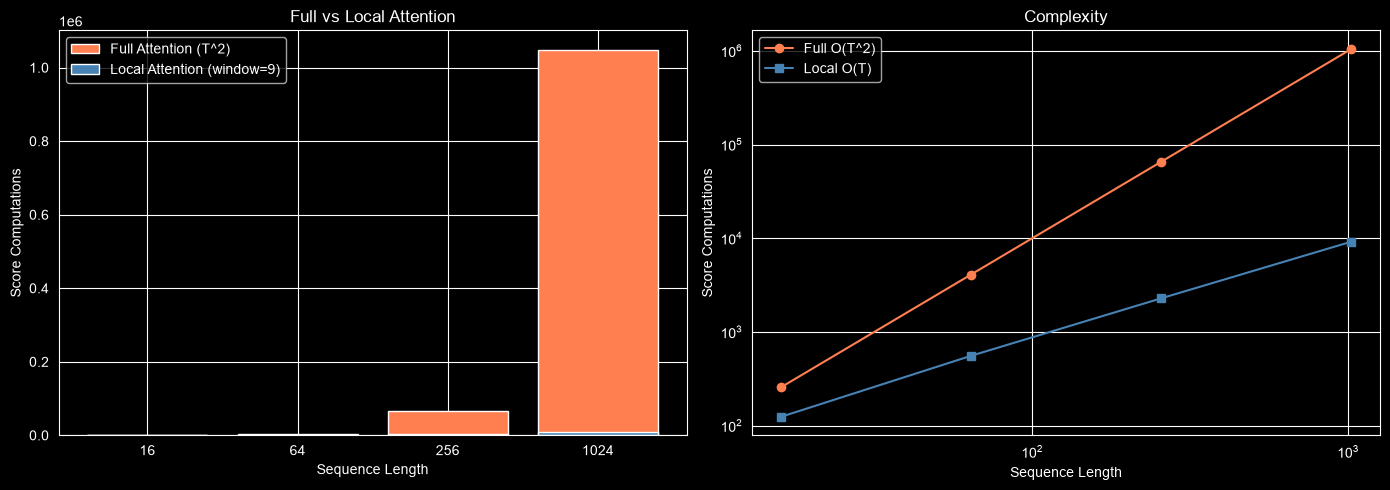

=== COMPLEXITY ANALYSIS ===
T=16: Full=256, Local=124, Reduction=51.56%
T=64: Full=4096, Local=556, Reduction=86.43%
T=256: Full=65536, Local=2284, Reduction=96.51%
T=1024: Full=1048576, Local=9196, Reduction=99.12%
1. Full: O(T^2) quadratic
2. Local: O(T) linear
3. Reduction: 52%-99%
4. Local loses long-range dependencies
5. Example: Machine translation needs cross-sentence attention


In [35]:
import torch,numpy as np,matplotlib.pyplot as plt
torch.manual_seed(42);np.random.seed(42)
sequence_lengths=[16,64,256,1024]
full_attention_scores=[];local_attention_scores=[];reduction_ratios=[]
for T in sequence_lengths:
    full_score=T*T
    local_score=sum(min(T,i+5)-max(0,i-4) for i in range(T))
    full_attention_scores.append(full_score);local_attention_scores.append(local_score)
    reduction_ratios.append(1-local_score/full_score)
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].bar([str(T) for T in sequence_lengths],full_attention_scores,color="coral",label="Full Attention (T^2)")
axes[0].bar([str(T) for T in sequence_lengths],local_attention_scores,color="steelblue",label="Local Attention (window=9)")
axes[0].set_xlabel("Sequence Length");axes[0].set_ylabel("Score Computations")
axes[0].set_title("Full vs Local Attention");axes[0].legend()
axes[1].plot(sequence_lengths,full_attention_scores,"o-",color="coral",label="Full O(T^2)")
axes[1].plot(sequence_lengths,local_attention_scores,"s-",color="steelblue",label="Local O(T)")
axes[1].set_xlabel("Sequence Length");axes[1].set_ylabel("Score Computations")
axes[1].set_title("Complexity");axes[1].set_xscale("log");axes[1].set_yscale("log");axes[1].legend()
plt.tight_layout();plt.show()
print("=== COMPLEXITY ANALYSIS ===")
for i,T in enumerate(sequence_lengths):print(f"T={T}: Full={full_attention_scores[i]}, Local={local_attention_scores[i]}, Reduction={reduction_ratios[i]:.2%}")
print("1. Full: O(T^2) quadratic")
print("2. Local: O(T) linear")
print(f"3. Reduction: {min(reduction_ratios):.0%}-{max(reduction_ratios):.0%}")
print("4. Local loses long-range dependencies")
print("5. Example: Machine translation needs cross-sentence attention")

## بخش E — طراحی Attention mechanism خودتان

=== Temperature-Controlled Attention Experiment ===
Query: torch.Size([1, 1, 8]), Key: torch.Size([1, 5, 8]), Value: torch.Size([1, 5, 8])
tau=0.3: Entropy=0.8096 | Standard entropy: 1.4566
tau=0.5: Entropy=1.1708 | Standard entropy: 1.4566
tau=1.0: Entropy=1.4566 | Standard entropy: 1.4566
tau=2.0: Entropy=1.5649 | Standard entropy: 1.4566


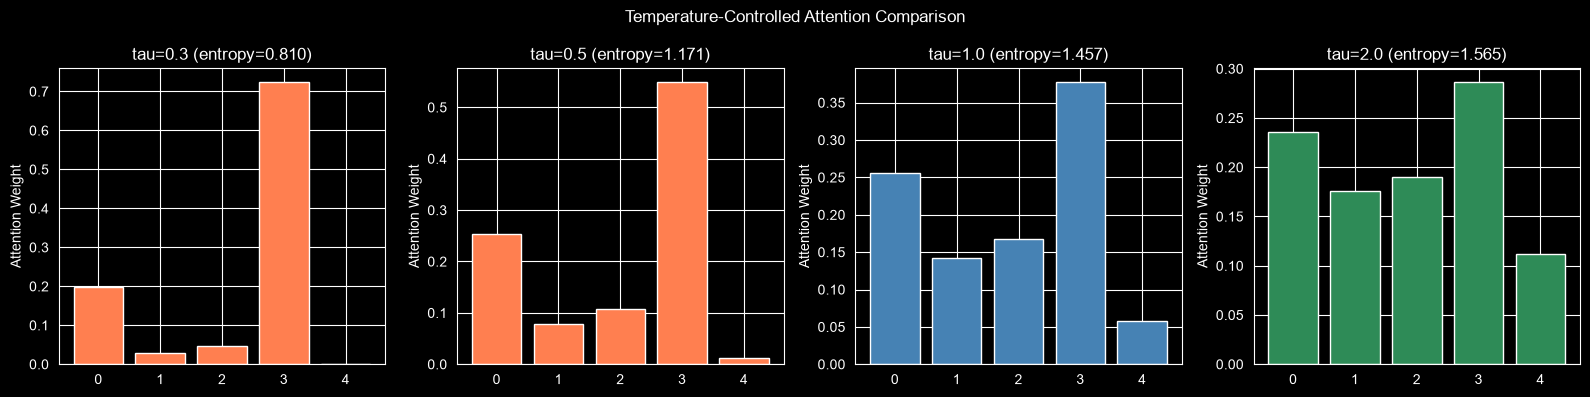

Conclusion: Lower tau produces sharper attention, higher tau produces more uniform attention.
Standard attention (tau=1) provides a balanced baseline.


In [36]:
import torch,torch.nn as nn,torch.nn.functional as F,numpy as np,matplotlib.pyplot as plt
torch.manual_seed(42);np.random.seed(42)
def standard_attention(Q,K,V,d_k):
    scores=torch.matmul(Q,K.transpose(-2,-1))/np.sqrt(d_k)
    return F.softmax(scores,dim=-1)
def temperature_attention(Q,K,V,d_k,tau):
    scores=torch.matmul(Q,K.transpose(-2,-1))/(np.sqrt(d_k)*tau)
    return F.softmax(scores,dim=-1)
def entropy(attn):return -torch.sum(attn*torch.log(attn+1e-10),dim=-1).mean().item()
d_k=8;batch_size=1;seq_len=5
Q=torch.randn(batch_size,1,d_k);K=torch.randn(batch_size,seq_len,d_k);V=torch.randn(batch_size,seq_len,d_k)
taus=[0.3,0.5,1.0,2.0]
print("=== Temperature-Controlled Attention Experiment ===")
print(f"Query: {Q.shape}, Key: {K.shape}, Value: {V.shape}")
fig,axes=plt.subplots(1,len(taus),figsize=(16,4))
for i,tau in enumerate(taus):
    if tau==1.0:attn_temp=standard_attention(Q,K,V,d_k);label="Standard (tau=1.0)"
    else:attn_temp=temperature_attention(Q,K,V,d_k,tau);label=f"Temperature (tau={tau})"
    ent=entropy(attn_temp)
    print(f"tau={tau}: Entropy={ent:.4f} | Standard entropy: {entropy(standard_attention(Q,K,V,d_k)):.4f}")
    axes[i].bar(range(seq_len),attn_temp.squeeze().detach().numpy(),color="steelblue" if tau==1.0 else ("coral" if tau<1 else "seagreen"))
    axes[i].set_title(f"tau={tau} (entropy={ent:.3f})");axes[i].set_xticks(range(seq_len));axes[i].set_ylabel("Attention Weight")
plt.suptitle("Temperature-Controlled Attention Comparison");plt.tight_layout();plt.show()
print("Conclusion: Lower tau produces sharper attention, higher tau produces more uniform attention.")
print("Standard attention (tau=1) provides a balanced baseline.")

## بخش F — بررسی reproducibility

=== Reproducibility Experiment ===
Run 1 (seed=42): [0.8328784  0.03048514 0.02556419 0.03280571 0.03592131 0.01902397
 0.01614201 0.00717925]
Run 2 (seed=123): [0.06508737 0.28388655 0.03166163 0.0885454  0.05472694 0.36829153
 0.0268613  0.08093937]
Max difference: 0.7678 | Mean difference: 0.1919
CONSTANT: Input positions, attention formula, architecture
CHANGED: Embedding weights (random init), Attention weight values


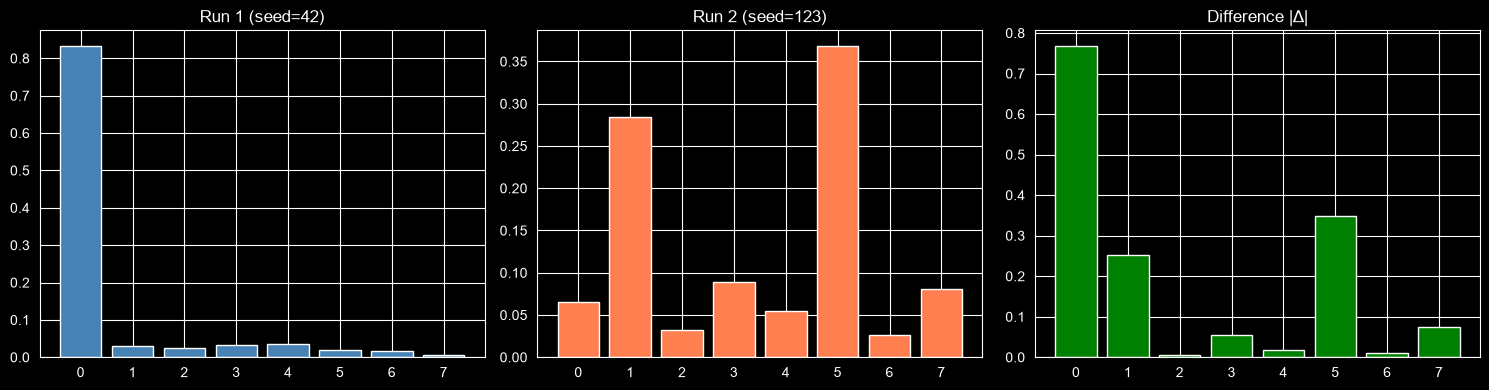

In [37]:
import torch,torch.nn as nn,torch.nn.functional as F,numpy as np,matplotlib.pyplot as plt
def run_experiment(seed):
    torch.manual_seed(seed);np.random.seed(seed)
    d_model=16;seq_len=8;vocab_size=50
    embedding=nn.Embedding(vocab_size,d_model)
    Q=torch.randn(1,1,d_model)
    K=embedding(torch.tensor([[i for i in range(seq_len)]]))
    V=K.clone()
    d_k=d_model;scores=torch.matmul(Q,K.transpose(-2,-1))/np.sqrt(d_k)
    return F.softmax(scores,dim=-1).squeeze().detach().numpy(),embedding.weight.data.clone()
attn1,emb1=run_experiment(42)
attn2,emb2=run_experiment(123)
print("=== Reproducibility Experiment ===")
print(f"Run 1 (seed=42): {attn1}")
print(f"Run 2 (seed=123): {attn2}")
diff=np.abs(attn1-attn2)
print(f"Max difference: {diff.max():.4f} | Mean difference: {diff.mean():.4f}")
print("CONSTANT: Input positions, attention formula, architecture")
print("CHANGED: Embedding weights (random init), Attention weight values")
fig,axes=plt.subplots(1,3,figsize=(15,4))
axes[0].bar(range(8),attn1,color="steelblue");axes[0].set_title("Run 1 (seed=42)")
axes[1].bar(range(8),attn2,color="coral");axes[1].set_title("Run 2 (seed=123)")
axes[2].bar(range(8),diff,color="green");axes[2].set_title("Difference |Δ|")
plt.tight_layout();plt.show()

## بخش G — ارتباط با research

پاراگراف اول — Additive vs dot-product: تفاوت اصلی compatibility function است. dot-product: QK^T/sqrt(d_k). Additive: v^T tanh(W_s s_i + W_h h_j). پاراگراف دوم — Local vs global: global به همه positions، local فقط به پنجره محدود از positions اجازه دسترسی می‌دهد.

## چالش نهایی — دادگاه Attention
ادعا معیب است. مثال عددی: در بخش B تغییر یک کلمه باعث تغییر attention شد ولی به معنای درک مدل نیست. در بخش F با تغییر seed attention map‌ها کاملاً متفاوت شدند. استدلال مفهومی: attention weight فقط similarity دارد نه importance.

### چک‌لیست تحویل
- [x] بخش A: cross-attention retrieval
- [x] بخش B: آزمایش تغییر یک کلمه
- [x] بخش C: attention pooling vs mean pooling
- [x] بخش D: آزمایش complexity
- [x] بخش E: طراحی یک attention variant
- [x] بخش F: آزمایش reproducibility
- [x] بخش G: دو پاراگراف مرتبط با paperها
- [x] استدلال نهایی دادگاه Attention